# MS600 - Week 6 - Recommender Systems - Michael Easton - October 6, 2026

## AI Use Disclosure:
To my knowledge I did not use AI to research, create, or complete any portion of this assignment; however, due to AI's integration into general internet searching functionality and many websites, it is possible debugging efforts may have inadvertantly included the use of AI. My intent is to primarily use source documentation for python, pandas, and other modules first before seeking answers through broader internet search.

# Instructions:

## Task 1:
 Perform some movie recommendations and analysis for user 2:
- How many movies has this user watched?
- Plot a bar chart of their movie ratings. The bar chart should be the counts of the number of unique ratings.
    - Hint: the `sort_index()` function from pandas might be helpful to make the bar plot look nicer.
- What are some of user 2's top movies?
    - Hint: to get the actual movie titles, you can use pandas [merge](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.merge.html) function, although using the movie IDs is OK too.
- Find the most similar user in the movielens dataset to user 2 using at least 2 distance metrics. Be sure to use cosine distance as one of your choices.
- Recommend a few movies for user 2 using similarity metrics.
- Do the recommendations from this method make sense?
- Write a short analysis of the results, and justify which similarity metric(s) you used.

More challenges to try:
- Perform other analyses (e.g. EDA, visualizations) of the movies watched from this dataset, or from a bigger part of the dataset for the movielens dataset: https://grouplens.org/datasets/movielens/
- Add yourself as a user in the data with ratings for movies you've watched, and find recommendations for next movies to watch. 
- Use a more advanced collaborative or content-based recommender to make recommendations (e.g. using the surprise package in Python)
    - Try making predictions for user 2. How do they compare with our basic model?
    - Add your own movie ratings, or use another recommender dataset and add your own preferences, then get recommendations for yourself

## Task 2: Prediction Log
Before you run the recommnender systems, write a one-sentence prediction of what you expect to find and why based on the EDA analysis you had already done. After your analysis, note whether you were right. This log should cover at least **3 predictions** tied to your data. Use the scaffold below.

Fill in at least 3 rows *before* running the recommender analysis. Add more rows if you like.

| # | My prediction (before analysis) | What I actually found | Was I right? |
|---|---|---|---|
| 1 | *I expect the Drama genre movies to be rated highest among the genres based on a loose impression that Drama's carrying more emotional weight translate to higher ratings.* | Looking into this analaysis revealed discrepencies in the data that I did not see until too late. | This is undetermined due to discrepencies in the data. The question to work out is why the Genre averages showing up as NaN? I suspect it might be related to how I split the genre data or due to missing genre information. |
| 2 | *I expect the average rating will increase the older the film is based on the notion that nostalgia can powerfully sway opinion.* | Plotted over time, closer to 1900 there was a great variability in movie ratings, which evens out through the 1960s, drops some in the 1990s-2000s, the spikes up. | Somewhat. Movies around the 1960s era were rated more consistantly. Earlier movies had wild variability in average ratings. This may need to be tempered by the number of movies released in each year. Further analysis required. |
| 3 | *I expect movies rated later in the day to have higher ratings because at the end of the day, we are more tired and less able to be critical of flaws.*| Ratings are highest at 5AM (3.67), 8AM (3.66) | It is unclear. After analysis I realized that this data does not define time zone of the timestamp provided, nor does it indicate the time zone of the user. 5AM and 8AM are relative to two factors that are not known.|

## Task 3: Critical Reflection
Reflect on the different approaches to performing recommender systems and say what you could do different and how that may impact your results? 3-5 sentences.


# Process Steps & Programming

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1.0 EDA & Cleaning

## 1.1 Data Cleaning

In [2]:
movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")
movies.head()


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [3]:
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  9742 non-null   int64
 1   title    9742 non-null   str  
 2   genres   9742 non-null   str  
dtypes: int64(1), str(2)
memory usage: 228.5 KB


### Pulling out Release Year

In [4]:
#Breakout Release Year from Title
#x = "Toy Story (1995)"
def yearBreak(y):
    """
    Pulls a year out of parenthetical brackets and turns it into an integer.
    """
    word_list = y.split()
    word_list[-1] = word_list[-1].strip('()')
    for word_index in range(len(word_list)):
        try:  
            year = int(word_list[word_index])
            word_list.pop()
            title = " ".join(word_list)
            return [title, year]
        except:
            continue

In [5]:
temp_break_list = []
error_log_movies = {}
movies['release'] = 0
movies['movie_title'] = ' '
for title_index in range(len(movies['title'])):
    temp_break_list = yearBreak(movies['title'][title_index])
    try:
        movies.at[title_index, 'movie_title'] = temp_break_list[0]
        movies.at[title_index, 'release'] = temp_break_list[1]
    except:
        movies.at[title_index, 'movie_title'] = movies.at[title_index, 'title']
        movies.at[title_index, 'release'] = 0
        error_log_movies[title_index] = [int(movies.at[title_index,'movieId']), str(movies.at[title_index, 'title'])]
movies.head()

,movieId,title,genres,release,movie_title
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995,Toy Story
1,2,Jumanji (1995),Adventure|Children|Fantasy,1995,Jumanji
2,3,Grumpier Old Men (1995),Comedy|Romance,1995,Grumpier Old Men
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,1995,Waiting to Exhale
4,5,Father of the Bride Part II (1995),Comedy,1995,Father of the Bride Part II


In [6]:
error_log_movies

{9031: [140956, 'Ready Player One'],
 9091: [143410, 'Hyena Road'],
 9138: [147250, 'The Adventures of Sherlock Holmes and Doctor Watson'],
 9179: [149334, 'Nocturnal Animals'],
 9259: [156605, 'Paterson'],
 9367: [162414, 'Moonlight'],
 9448: [167570, 'The OA'],
 9514: [171495, 'Cosmos'],
 9515: [171631, 'Maria Bamford: Old Baby'],
 9518: [171749, 'Death Note: Desu nôto (2006–2007)'],
 9611: [176601, 'Black Mirror']}

In [7]:
"""
This is a small list of missing years. While not reasonable if the list of missings were larger,
I'll manually add the release years in. It appears some of these are TV series as well which
might be warranted for removal eventually. 
"""
release_index = list(error_log_movies.keys())
release_years = [2018, 2015, 1979, 2016, 2016, 2016, 2016, 2019, 2017, 2006, 2011]

for ri in range(len(release_index)):
    movies.at[release_index[ri], 'release'] = release_years[ri]

movies.at[9091, 'release']

np.int64(2015)

In [8]:
movies.head()

,movieId,title,genres,release,movie_title
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995,Toy Story
1,2,Jumanji (1995),Adventure|Children|Fantasy,1995,Jumanji
2,3,Grumpier Old Men (1995),Comedy|Romance,1995,Grumpier Old Men
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,1995,Waiting to Exhale
4,5,Father of the Bride Part II (1995),Comedy,1995,Father of the Bride Part II


### Separating Genres

In [9]:
movies['genres'].value_counts()

genres
Drama                                     1053
Comedy                                     946
Comedy|Drama                               435
Comedy|Romance                             363
Drama|Romance                              349
                                          ... 
Adventure|Mystery|Sci-Fi|Thriller            1
Action|Comedy|Crime|Horror                   1
Action|Adventure|Children|Sci-Fi             1
Action|Adventure|Comedy|Fantasy|Sci-Fi       1
Action|Animation|Comedy|Fantasy              1
Name: count, Length: 951, dtype: int64

In [10]:
genre_list_rough = []
for mgi in range(len(movies['genres'])):
    split_genres = movies.at[mgi, 'genres'].split('|')
    for mg_sub in range(len(split_genres)):
        genre_list_rough.append(split_genres[mg_sub])
genre_list = set(genre_list_rough)
genre_list

{'(no genres listed)',
 'Action',
 'Adventure',
 'Animation',
 'Children',
 'Comedy',
 'Crime',
 'Documentary',
 'Drama',
 'Fantasy',
 'Film-Noir',
 'Horror',
 'IMAX',
 'Musical',
 'Mystery',
 'Romance',
 'Sci-Fi',
 'Thriller',
 'War',
 'Western'}

In [11]:
for mgi2 in range(len(movies['genres'])):
    split_genres2 = movies.at[mgi2, 'genres'].split('|')
    for sg2 in split_genres2:
        for genre in genre_list:
            if sg2 == genre:
                movies.at[mgi2, genre] = 1
            else:
                continue
movies.head()

for genre2 in genre_list:
    movies[genre2] = movies[genre2].fillna(0)
movies.head()

,movieId,title,genres,release,movie_title,Adventure,Animation,Children,Comedy,Fantasy,...,Horror,Mystery,Sci-Fi,War,Musical,Documentary,IMAX,Western,Film-Noir,(no genres listed)
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995,Toy Story,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,Jumanji (1995),Adventure|Children|Fantasy,1995,Jumanji,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,Grumpier Old Men (1995),Comedy|Romance,1995,Grumpier Old Men,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,1995,Waiting to Exhale,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,Father of the Bride Part II (1995),Comedy,1995,Father of the Bride Part II,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Converting Rating Timestamps

In [12]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [13]:
# Changine the timestamps to datetime
ratings['timestamp'] = pd.to_datetime(ratings['timestamp'], unit='s')
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,2000-07-30 18:45:03
1,1,3,4.0,2000-07-30 18:20:47
2,1,6,4.0,2000-07-30 18:37:04
3,1,47,5.0,2000-07-30 19:03:35
4,1,50,5.0,2000-07-30 18:48:51


In [14]:
ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype        
---  ------     --------------   -----        
 0   userId     100836 non-null  int64        
 1   movieId    100836 non-null  int64        
 2   rating     100836 non-null  float64      
 3   timestamp  100836 non-null  datetime64[s]
dtypes: datetime64[s](1), float64(1), int64(2)
memory usage: 3.1 MB


In [15]:
ratings_check = ratings[ratings.isna()==True]
ratings_check.value_counts()
# It appears that there is no missing data in the ratings Database. 

Series([], Name: count, dtype: int64)

## 1.2 Basic EDA

### Hypothesis 1

In [16]:
movies.head()

,movieId,title,genres,release,movie_title,Adventure,Animation,Children,Comedy,Fantasy,...,Horror,Mystery,Sci-Fi,War,Musical,Documentary,IMAX,Western,Film-Noir,(no genres listed)
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995,Toy Story,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,Jumanji (1995),Adventure|Children|Fantasy,1995,Jumanji,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,Grumpier Old Men (1995),Comedy|Romance,1995,Grumpier Old Men,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,1995,Waiting to Exhale,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,Father of the Bride Part II (1995),Comedy,1995,Father of the Bride Part II,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
#genre_movie = list(movies[movies['Adventure']==1].index)
#genre_movie[3]

mean_rating = []
for g in genre_list:
    genre_movie = list(movies[movies[g]==1].index)
    mean_rating_list = []
    for gM in genre_movie:
        mean_rating_list.append(float(ratings[ratings['movieId'] == gM]['rating'].mean()))
    mean_rating.append([g,round(sum(mean_rating_list)/len(mean_rating_list),2)])
mean_rating

[['Thriller', nan],
 ['Film-Noir', nan],
 ['Mystery', nan],
 ['War', nan],
 ['Fantasy', nan],
 ['Western', nan],
 ['IMAX', nan],
 ['Sci-Fi', nan],
 ['Romance', nan],
 ['Musical', nan],
 ['Animation', nan],
 ['Horror', nan],
 ['Action', nan],
 ['Crime', nan],
 ['Drama', nan],
 ['(no genres listed)', nan],
 ['Comedy', nan],
 ['Documentary', nan],
 ['Children', nan],
 ['Adventure', nan]]

Something is wrong with this. I suspect there's some issue in the data.

### Hypothesis 2 

In [18]:
movies['release'].value_counts()

release
2002    299
2001    286
2006    286
2000    278
1996    271
       ... 
0         1
31        1
19        1
2019      1
2049      1
Name: count, Length: 184, dtype: int64

In [19]:
# Late in the process revelations that release year might be inaccurate. 

In [20]:
release_list = list(set(movies['release']))

remove_list = []
for release_list_item in release_list:
    if release_list_item < 1900:
        remove_list.append(release_list_item)
    elif release_list_item > 2026:
        remove_list.append(release_list_item)

for remove_list_item in remove_list:
    release_list.remove(remove_list_item)

#release_list

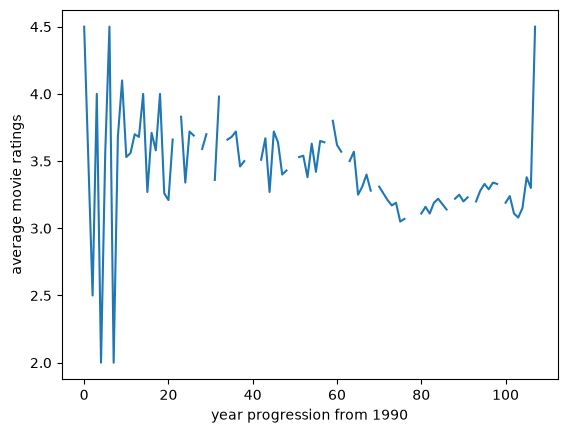

In [70]:
release_movies = (movies[movies['release']==2002].index)
release_movies

mean_release_rating = []
for r in release_list:
    mean_release = list(movies[movies['release']==r].index)
    mean_rel_rating_list = []
    for rel_mov_item in mean_release:
        mean_rel_rating_list.append(float(ratings[ratings['movieId'] == rel_mov_item]['rating'].mean()))
    mean_release_rating.append([r,round(sum(mean_rel_rating_list)/len(mean_rel_rating_list),2)])

#mean_release_rating

t = [r_i[1] for r_i in mean_release_rating]
s = range(len(t))

fig, ax = plt.subplots()
ax.plot(s,t)
ax.set(xlabel='year progression from 1990', ylabel='average movie ratings')
plt.show()

### Hypothesis 3

In [22]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,2000-07-30 18:45:03
1,1,3,4.0,2000-07-30 18:20:47
2,1,6,4.0,2000-07-30 18:37:04
3,1,47,5.0,2000-07-30 19:03:35
4,1,50,5.0,2000-07-30 18:48:51


In [23]:
hour_rating_list = []
hour_list = []
for i in range(len(ratings)):
    hour_rating_list.append(ratings['rating'][i])
    hour_list.append(ratings['timestamp'][i].hour)

In [24]:
hour_dict = {'hour':hour_list, 'rating':hour_rating_list}
hour_DF = pd.DataFrame(data=hour_dict)

In [25]:
tr_list = []
for time_hour in range(0,24):
    tr_list.append([time_hour,round(float(hour_DF[hour_DF['hour']==time_hour]['rating'].sum()/hour_DF[hour_DF['hour']==time_hour]['rating'].count()),2)])
tr_list

[[0, 3.46],
 [1, 3.46],
 [2, 3.46],
 [3, 3.5],
 [4, 3.51],
 [5, 3.67],
 [6, 3.61],
 [7, 3.61],
 [8, 3.66],
 [9, 3.44],
 [10, 3.48],
 [11, 3.48],
 [12, 3.52],
 [13, 3.62],
 [14, 3.48],
 [15, 3.48],
 [16, 3.56],
 [17, 3.56],
 [18, 3.54],
 [19, 3.43],
 [20, 3.41],
 [21, 3.46],
 [22, 3.41],
 [23, 3.51]]

Ratings are highest at 5AM (3.67), 8AM (3.66) however this does not identify the time zone and it is unclear if users are confined to specific time zones.

## 1.3 User 2 EDA

In [26]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,2000-07-30 18:45:03
1,1,3,4.0,2000-07-30 18:20:47
2,1,6,4.0,2000-07-30 18:37:04
3,1,47,5.0,2000-07-30 19:03:35
4,1,50,5.0,2000-07-30 18:48:51


In [27]:
ratings_user2 = ratings[ratings['userId']==2]
ratings_user2.info()

<class 'pandas.DataFrame'>
RangeIndex: 29 entries, 232 to 260
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype        
---  ------     --------------  -----        
 0   userId     29 non-null     int64        
 1   movieId    29 non-null     int64        
 2   rating     29 non-null     float64      
 3   timestamp  29 non-null     datetime64[s]
dtypes: datetime64[s](1), float64(1), int64(2)
memory usage: 1.0 KB


['2.0', '2.5', '3.0', '3.5', '4.0', '4.5', '5.0']
{'Count': array([1, 1, 4, 4, 9, 4, 6])}


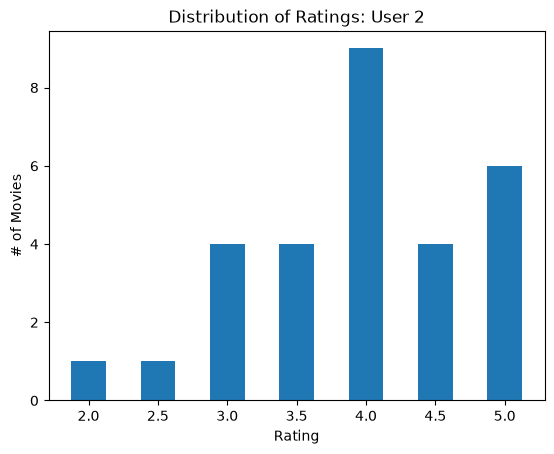

In [28]:
ru2_ratings = [str(ru2r) for ru2r in (sorted(set(ratings_user2['rating'])))]
print(ru2_ratings)
rating_counts = {"Count": np.array((ratings_user2.groupby('rating'))['rating'].count())}
print(rating_counts)
width = 0.5
rating_counts

fig, cx = plt.subplots()
bottom = np.zeros(7)

for boolean, rating_count in rating_counts.items():
    r = cx.bar(ru2_ratings, rating_count, width, label=boolean, bottom=bottom)
    bottom += rating_count

cx.set(xlabel='Rating', ylabel='# of Movies',
       title='Distribution of Ratings: User 2')

plt.show()

In [29]:
user2_top6_DF = ratings_user2[ratings_user2['rating']==5]
user2_top6List = list(user2_top6_DF['movieId'])

movies.set_index('movieId', inplace=True)

print("User 2's Top 6 Movies:")
for u2t6_index in user2_top6List:
    print(str("- ")+movies['movie_title'][u2t6_index])

User 2's Top 6 Movies:
- Step Brothers
- Inside Job
- Warrior
- Wolf of Wall Street, The
- Mad Max: Fury Road
- The Jinx: The Life and Deaths of Robert Durst


# 2.0 Recommenders

## 2.1 Collaborative Filters

In [30]:
#Top 5 Films - Merged Ratings/Movies
#Re-uploading the ratings DF as Timestamp objects do not sum together. 
ratings_merge = pd.read_csv("ratings.csv")
rm_DF = pd.concat([movies, ratings_merge.groupby('movieId').sum()], axis=1).sort_values(by='rating', ascending=False)
rm_DF.head()

,title,genres,release,movie_title,Adventure,Animation,Children,Comedy,Fantasy,Romance,...,War,Musical,Documentary,IMAX,Western,Film-Noir,(no genres listed),userId,rating,timestamp
movieId,,,,,,,,,,,,,,,,,,,,,
318,"Shawshank Redemption, The (1994)",Crime|Drama,1994,"Shawshank Redemption, The",0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,95829.0,1404.0,3.769248e+11
356,Forrest Gump (1994),Comedy|Drama|Romance|War,1994,Forrest Gump,0.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,101385.0,1370.0,3.861652e+11
296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,1994,Pulp Fiction,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,90621.0,1288.5,3.492043e+11
2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller,1999,"Matrix, The",0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,85236.0,1165.5,3.502700e+11
593,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller,1991,"Silence of the Lambs, The",0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,85535.0,1161.0,3.200357e+11


In [31]:
#Collaborative Filtering - Leaving the NAs as is
ratings_wide_NA = ratings.pivot(index='userId', columns='movieId', values='rating')
ratings_wide_NA.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2.1.1 Pearson Correlation Based Recommendation

In [32]:
# DataFrame.T: Transpose the Dataframe -   [a b c]  ->  [a
#                                                        b
#                                                        c]
ratings_cor_NA = ratings_wide_NA.T.corr()
ratings_cor_NA.head()

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
userId,,,,,,,,,,,,,,,,,,,,,
1,1.000000,NaN,0.079819,0.207983,0.268749,-0.291636,-0.118773,0.469668,0.918559,-0.037987,...,9.157371e-02,-1.597727e-16,-0.061503,-0.407556,-0.164871,0.066378,0.174557,0.268070,-0.175412,-0.032086
2,NaN,1.0,NaN,NaN,NaN,NaN,-0.991241,NaN,NaN,0.037796,...,-3.873468e-01,NaN,-1.000000,NaN,NaN,0.583333,NaN,-0.125000,NaN,0.623288
3,0.079819,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.433200,NaN,NaN,-0.791334,-0.333333,-0.395092,NaN,0.569562
4,0.207983,NaN,NaN,1.000000,-0.336525,0.148498,0.542861,0.117851,NaN,0.485794,...,-2.221127e-01,3.966413e-01,0.090090,-0.080296,0.400124,0.144603,0.116518,-0.170501,-0.277350,-0.043786
5,0.268749,NaN,NaN,-0.336525,1.000000,0.043166,0.158114,0.028347,NaN,-0.777714,...,2.719480e-16,1.533034e-01,0.234743,0.067791,-0.364156,0.244321,0.231080,-0.020546,0.384111,0.040582


In [33]:
#Sort to find Users most similar to User 2
ratings_cor_NA.loc[2].sort_values(ascending=False)

userId
2      1.0
33     1.0
34     1.0
93     1.0
60     1.0
      ... 
602    NaN
604    NaN
605    NaN
607    NaN
609    NaN
Name: 2, Length: 610, dtype: float64

In [34]:
#Collaborative Filtering - Setting NAs to 0
ratings_wide_zero = ratings.pivot(index='userId', columns='movieId', values='rating')
ratings_wide_zero.fillna(0, inplace=True)
ratings_cor_zero = ratings_wide_zero.T.corr()
ratings_cor_zero.loc[2].sort_values(ascending=False)

userId
2      1.000000
366    0.297982
417    0.277366
378    0.273342
550    0.252051
         ...   
234   -0.007464
605   -0.007919
312   -0.007996
104   -0.008897
217   -0.013222
Name: 2, Length: 610, dtype: float64

In [35]:
#Collaborative Filtering - Setting NAs to -1
ratings_wide_none = ratings.pivot(index='userId', columns='movieId', values='rating')
ratings_wide_none.fillna(-1, inplace=True)
ratings_cor_none = ratings_wide_none.T.corr()
ratings_cor_none.loc[2].sort_values(ascending=False)

userId
2      1.000000
366    0.300528
378    0.277953
417    0.277085
550    0.252587
         ...   
234   -0.007649
605   -0.008081
312   -0.008135
104   -0.009044
217   -0.013622
Name: 2, Length: 610, dtype: float64

In [36]:
ratings_wide_none.loc[2].notna().equals(ratings_wide_none.loc[366].notna())

True

In [37]:
movies.head()

,title,genres,release,movie_title,Adventure,Animation,Children,Comedy,Fantasy,Romance,...,Horror,Mystery,Sci-Fi,War,Musical,Documentary,IMAX,Western,Film-Noir,(no genres listed)
movieId,,,,,,,,,,,,,,,,,,,,,
1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995,Toy Story,1.0,1.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Jumanji (1995),Adventure|Children|Fantasy,1995,Jumanji,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Grumpier Old Men (1995),Comedy|Romance,1995,Grumpier Old Men,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Waiting to Exhale (1995),Comedy|Drama|Romance,1995,Waiting to Exhale,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,Father of the Bride Part II (1995),Comedy,1995,Father of the Bride Part II,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [38]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,2000-07-30 18:45:03
1,1,3,4.0,2000-07-30 18:20:47
2,1,6,4.0,2000-07-30 18:37:04
3,1,47,5.0,2000-07-30 19:03:35
4,1,50,5.0,2000-07-30 18:48:51


In [39]:
rm_DF = rm_DF.reset_index()
rm_DF.head()

,movieId,title,genres,release,movie_title,Adventure,Animation,Children,Comedy,Fantasy,...,War,Musical,Documentary,IMAX,Western,Film-Noir,(no genres listed),userId,rating,timestamp
0,318,"Shawshank Redemption, The (1994)",Crime|Drama,1994,"Shawshank Redemption, The",0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,95829.0,1404.0,3.769248e+11
1,356,Forrest Gump (1994),Comedy|Drama|Romance|War,1994,Forrest Gump,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,101385.0,1370.0,3.861652e+11
2,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,1994,Pulp Fiction,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,90621.0,1288.5,3.492043e+11
3,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller,1999,"Matrix, The",0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,85236.0,1165.5,3.502700e+11
4,593,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller,1991,"Silence of the Lambs, The",0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,85535.0,1161.0,3.200357e+11


### 2.1.2 Movie Recommender Function - Recommends movies by comparing two users ratings

In [40]:
def movieRecommender(Wide_Ratings, Rating_Movie_DF, user_y, user_x):
    """
    User Y is the user that the recommendations are for. Recommendations are based upon User X. 
    Outputs recommendations based on movies rated by User X not rated by User Y.
    Sorts recommendations first by User X's ratings then by relative Global Ratings.
    Larger Global Ratings mean more highly rated and/or having received more ratings in general.

    movieDF must be Collaborative Filtered DF - UserID (index) vs. MovieID (columns)
    Assumes unrated movies are NaN.
    """
    #movies rated by user x (recommendation source)
    user_x_rated_movies = set((Wide_Ratings.loc[user_x].dropna()).index)

    #movies already reated by user_x
    user_y_rated_movies = set((Wide_Ratings.loc[user_y].dropna()).index)

    #keep user_x moves that user_2 has not rated
    movies_for_user_y = []
    for uXm in user_x_rated_movies:
        if uXm not in user_y_rated_movies:
            movies_for_user_y.append(uXm)
        else:
            pass        

    #sort by user_x's highest ratings
    user_x_movie_ratings = []
    global_movie_ratings = []
    rec_movie_titles = []
    for rMr in range(len(movies_for_user_y)):
        user_x_movie_ratings.append(Wide_Ratings[movies_for_user_y[rMr]][user_x])
        global_movie_ratings.append(Rating_Movie_DF[(Rating_Movie_DF['movieId'] == movies_for_user_y[rMr])]['rating'].sum())
        rec_movie_titles.append(Rating_Movie_DF[(Rating_Movie_DF['movieId'] == movies_for_user_y[rMr])]['movie_title'].values)
    
    rec_dict = {"movie title": rec_movie_titles, "userX": user_x_movie_ratings, "global": global_movie_ratings}
    recommendation_DF = pd.DataFrame(data=rec_dict, index=movies_for_user_y)
    print("Recommendations for User Y, Sorted by User X's Ratings then Global Ratings")
    print(recommendation_DF.sort_values(by=['userX','global'], ascending=False).head(10))
    return recommendation_DF

#rm_DF['movieId']
user366 = movieRecommender(ratings_wide_NA, rm_DF, 2, 366)

Recommendations for User Y, Sorted by User X's Ratings then Global Ratings
                                              movie title  userX  global
1089                                     [Reservoir Dogs]    5.0   550.5
2959                                         [Fight Club]    4.5   931.5
4993    [Lord of the Rings: The Fellowship of the Ring...    4.5   813.0
7153     [Lord of the Rings: The Return of the King, The]    4.5   762.0
8368           [Harry Potter and the Prisoner of Azkaban]    4.5   364.0
116797                               [The Imitation Game]    4.5   201.0
110                                          [Braveheart]    4.0   955.5
589                          [Terminator 2: Judgment Day]    4.0   889.5
2028                                [Saving Private Ryan]    4.0   779.5
6539    [Pirates of the Caribbean: The Curse of the Bl...    4.0   563.0


### 2.1.3 Euclidean Distances

In [41]:
from scipy.spatial.distance import euclidean
from scipy.spatial.distance import pdist, squareform

#def euclidean_distance(vector1, vector2):
    #return np.sqrt(np.sum((vector1 - vector2) ** 2))

#def euclidean_distance(vector1, vector2):
    #return np.linalg.norm(vector1 - vector2)

In [42]:
#using the transposed movie rating data frame where NaN was replace with -1
ratings_wide_none.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,-1.0,4.0,-1.0,-1.0,4.0,-1.0,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
2,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
3,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
4,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
5,4.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0


In [43]:
euclidean(ratings_wide_none.iloc[2], ratings_wide_none.iloc[366])

np.float64(71.76001672240608)

In [44]:
euclidean_distances = squareform(pdist(ratings_wide_none, metric="euclidean"))
euclidean_df = pd.DataFrame(data=euclidean_distances, columns=ratings_wide_none.index, index=ratings_wide_none.index)
euclidean_df.head()

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
userId,,,,,,,,,,,,,,,,,,,,,
1,0.000000,86.239492,84.731930,96.979379,84.516271,108.083301,91.651514,84.380092,86.203248,96.969067,...,95.430603,90.288427,147.939177,91.350972,96.224997,165.230143,90.862534,126.232920,84.279298,179.904836
2,86.239492,0.000000,36.806929,74.567084,41.039615,84.777650,60.172668,41.318882,40.450587,57.295288,...,55.859198,58.423026,145.090489,52.822817,69.235107,158.923724,71.674612,124.893955,37.016888,171.373860
3,84.731930,36.806929,0.000000,73.908727,39.956226,84.584277,60.112395,40.441316,39.172695,58.150666,...,59.895743,57.701820,144.296570,51.850747,68.233057,158.848985,70.664701,124.946989,36.173194,172.971819
4,96.979379,74.567084,73.908727,0.000000,72.608539,101.847926,83.330667,74.639132,75.591005,85.743804,...,84.604964,81.455509,137.952891,81.018516,90.461318,158.726179,89.693924,131.524713,73.593478,178.462181
5,84.516271,41.039615,39.956226,72.608539,0.000000,77.479029,59.958319,33.837849,43.543082,60.274373,...,61.253571,48.383882,142.762040,47.833043,66.740168,157.171880,69.188149,122.697799,35.270384,172.935682


In [45]:
euclidean_df.loc[2].sort_values()

userId
2        0.000000
442     29.000000
461     30.495901
189     30.809901
508     31.488093
          ...    
448    171.200175
610    171.373860
599    185.184368
474    206.630709
414    232.408046
Name: 2, Length: 610, dtype: float64

In [46]:
print("Euclidean Distance: Most similar is User "+str(int(euclidean_df.loc[2].sort_values().index[1]))+" with a Euclidean Coeff of "+str(round(float(euclidean_df.loc[2].sort_values().loc[442]),2))+".")
print("Pearson Correlation: Most similar is User "+str(366)+" with a Euclidean Coeff of "+str(round(float(euclidean_df.loc[2].sort_values().loc[366]),2))+".")

Euclidean Distance: Most similar is User 442 with a Euclidean Coeff of 29.0.
Pearson Correlation: Most similar is User 366 with a Euclidean Coeff of 32.37.


In [47]:
user442 = movieRecommender(ratings_wide_NA, rm_DF, 2, 442)

Recommendations for User Y, Sorted by User X's Ratings then Global Ratings
                                            movie title  userX  global
362                                  [Jungle Book, The]    2.5   120.0
4361                                          [Tootsie]    2.5   109.5
3752                               [Me, Myself & Irene]    2.0   142.0
2908                                   [Boys Don't Cry]    2.0   138.5
524                                              [Rudy]    2.0   118.5
2145                                   [Pretty in Pink]    2.0   107.0
3363                                [American Graffiti]    1.5   165.5
616                                   [Aristocats, The]    1.5   153.5
468   [Englishman Who Went Up a Hill But Came Down a...    1.5    70.5
3510                                        [Frequency]    1.0   123.0


### 2.1.4 Cosine Distances

In [48]:
from scipy.spatial.distance import cosine

In [49]:
#using the transposed movie rating data frame where NaN was replace with -1
ratings_wide_none.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,-1.0,4.0,-1.0,-1.0,4.0,-1.0,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
2,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
3,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
4,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
5,4.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0


In [50]:
cosine_distances = squareform(pdist(ratings_wide_none, metric='cosine'))
cosine_df = pd.DataFrame(cosine_distances, columns=ratings_wide_none.index, index=ratings_wide_none.index)
cosine_df.loc[2].sort_values()

userId
2      0.000000
442    0.042025
461    0.046059
189    0.046957
508    0.049443
         ...   
610    0.762312
448    0.817785
599    0.936812
474    0.975777
414    1.084648
Name: 2, Length: 610, dtype: float64

The Cosine Distance has the same Top 5 Similar Users as the Euclidean method, but both are unique from the Pearson Correlation Method.

Below are just looking into the other top 5 recommended users.

In [51]:
user461 = movieRecommender(ratings_wide_NA, rm_DF, 2, 461)

Recommendations for User Y, Sorted by User X's Ratings then Global Ratings
                      movie title  userX  global
356                [Forrest Gump]    5.0  1370.0
1784         [As Good as It Gets]    4.5   355.0
1246         [Dead Poets Society]    4.5   340.5
593   [Silence of the Lambs, The]    4.0  1161.0
2762           [Sixth Sense, The]    4.0   697.0
1213                 [Goodfellas]    4.0   535.5
3147            [Green Mile, The]    4.0   460.5
587                       [Ghost]    4.0   395.0
539        [Sleepless in Seattle]    4.0   368.0
1259                [Stand by Me]    4.0   364.5


In [52]:
user189 = movieRecommender(ratings_wide_NA, rm_DF, 2, 189)

Recommendations for User Y, Sorted by User X's Ratings then Global Ratings
                                             movie title  userX  global
527                                   [Schindler's List]    4.5   929.5
68954                                               [Up]    4.5   420.5
54286                            [Bourne Ultimatum, The]    4.5   299.5
356                                       [Forrest Gump]    4.0  1370.0
2571                                       [Matrix, The]    4.0  1165.5
593                          [Silence of the Lambs, The]    4.0  1161.0
2959                                        [Fight Club]    4.0   931.5
4993   [Lord of the Rings: The Fellowship of the Ring...    4.0   813.0
7153    [Lord of the Rings: The Return of the King, The]    4.0   762.0
5952            [Lord of the Rings: The Two Towers, The]    4.0   756.0


In [53]:
user508 = movieRecommender(ratings_wide_NA, rm_DF, 2, 508)

Recommendations for User Y, Sorted by User X's Ratings then Global Ratings
                                    movie title  userX  global
1270                       [Back to the Future]    4.5   690.5
1222                        [Full Metal Jacket]    4.5   418.0
2011               [Back to the Future Part II]    4.0   305.0
2012              [Back to the Future Part III]    4.0   296.5
671   [Mystery Science Theater 3000: The Movie]    2.5   125.5
562                  [Welcome to the Dollhouse]    2.5    81.5
898                   [Philadelphia Story, The]    2.0   125.0
3396                        [Muppet Movie, The]    2.0   118.5
2243                           [Broadcast News]    2.0    96.0
1952                          [Midnight Cowboy]    2.0    87.0


In [54]:
print(user442.sort_values(by=['userX','global'], ascending=False).head(10))

                                            movie title  userX  global
362                                  [Jungle Book, The]    2.5   120.0
4361                                          [Tootsie]    2.5   109.5
3752                               [Me, Myself & Irene]    2.0   142.0
2908                                   [Boys Don't Cry]    2.0   138.5
524                                              [Rudy]    2.0   118.5
2145                                   [Pretty in Pink]    2.0   107.0
3363                                [American Graffiti]    1.5   165.5
616                                   [Aristocats, The]    1.5   153.5
468   [Englishman Who Went Up a Hill But Came Down a...    1.5    70.5
3510                                        [Frequency]    1.0   123.0


In [55]:
print(user366.head(10))

                                             movie title  userX  global
4993   [Lord of the Rings: The Fellowship of the Ring...    4.5   813.0
8961                                  [Incredibles, The]    4.0   479.5
33794                                    [Batman Begins]    4.0   448.0
6537                [Terminator 3: Rise of the Machines]    3.5   137.0
6539   [Pirates of the Caribbean: The Curse of the Bl...    4.0   563.0
1036                                          [Die Hard]    4.0   560.0
7438                                 [Kill Bill: Vol. 2]    4.0   425.5
2959                                        [Fight Club]    4.5   931.5
6942                                     [Love Actually]    3.5   223.5
44191                                   [V for Vendetta]    3.5   388.5


## 2.2 Scikit-Surprise Recommender

Note: I'm running this as presented in the Week 6 FTE. I will note if I make changes.

In [56]:
#%pip install scikit-surprise
from surprise import SVD
from surprise import BaselineOnly
from surprise import Dataset
from surprise import Reader
from surprise.model_selection import cross_validate

#path to dataset file
file_path = "ratings.csv"

reader = Reader(line_format='user item rating timestamp', sep=',', skip_lines=1)

data = Dataset.load_from_file(file_path, reader=reader)

cross_validate(SVD(), data, verbose=True)

Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8758  0.8813  0.8725  0.8722  0.8665  0.8736  0.0049  
MAE (testset)     0.6703  0.6781  0.6688  0.6696  0.6688  0.6711  0.0036  
Fit time          0.47    0.50    0.46    0.47    0.47    0.47    0.01    
Test time         0.07    0.10    0.07    0.13    0.07    0.09    0.02    


{'test_rmse': array([0.87583419, 0.88126169, 0.87251204, 0.8721666 , 0.86645474]),
 'test_mae': array([0.67027322, 0.67813813, 0.66877682, 0.6696158 , 0.66876826]),
 'fit_time': (0.46797823905944824,
  0.5025713443756104,
  0.4614558219909668,
  0.4677133560180664,
  0.46630072593688965),
 'test_time': (0.0713660717010498,
  0.10333943367004395,
  0.06768059730529785,
  0.13045501708984375,
  0.07372403144836426)}

In [57]:
training_data = data.build_full_trainset()
rec = SVD()
fitted = rec.fit(training_data)

In [58]:
prediction = rec.predict(uid='2', iid='5')
prediction

Prediction(uid='2', iid='5', r_ui=None, est=np.float64(2.7387457975527787), details={'was_impossible': False})

In [59]:
from collections import defaultdict

def get_top_n(predictions, n=10):
    """Return the top-N recommendation for each user from a set of predictions.
    Args:
        predictions(list of Prediction objects): The list of predictions, as
            returned by the test method of an algorithm.
        n(int): The number of recommendation to output for each user. Default
            is 10.
    Returns:
    A dict where keys are user (raw) ids and values are lists of tuples:
        [(raw item id, rating estimation), ...] of size n.
    """

    # First map the predictions to each user.
    top_n = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        top_n[uid].append((iid, est))

    # Then sort the predictions for each user and retrieve the k highest ones.
    for uid, user_ratings in top_n.items():
        user_ratings.sort(key=lambda x: x[1], reverse=True)
        top_n[uid] = user_ratings[:n]

    return top_n

In [60]:
testset = training_data.build_anti_testset()
predictions = rec.test(testset)

top_n = get_top_n(predictions)

top_user_2 = pd.DataFrame(data=top_n['2'], columns=['movieId', 'predicted_rating'])
top_user_2['movieId'] = top_user_2['movieId'].astype('int')
top_user_2.set_index('movieId', inplace=True)

predicted_top_user = top_user_2.merge(movies, left_index=True, right_index=True).head(20)
predicted_top_user

,predicted_rating,title,genres,release,movie_title,Adventure,Animation,Children,Comedy,Fantasy,...,Horror,Mystery,Sci-Fi,War,Musical,Documentary,IMAX,Western,Film-Noir,(no genres listed)
movieId,,,,,,,,,,,,,,,,,,,,,
1198,4.625535,Raiders of the Lost Ark (Indiana Jones and the...,Action|Adventure,1981,Raiders of the Lost Ark (Indiana Jones and the...,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
593,4.605076,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller,1991,"Silence of the Lambs, The",0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2959,4.605060,Fight Club (1999),Action|Crime|Drama|Thriller,1999,Fight Club,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
527,4.591539,Schindler's List (1993),Drama|War,1993,Schindler's List,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
296,4.560202,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,1994,Pulp Fiction,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1203,4.540276,12 Angry Men (1957),Drama,12,12 Angry Men,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
356,4.493065,Forrest Gump (1994),Comedy|Drama|Romance|War,1994,Forrest Gump,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1089,4.474130,Reservoir Dogs (1992),Crime|Mystery|Thriller,1992,Reservoir Dogs,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1204,4.467695,Lawrence of Arabia (1962),Adventure|Drama|War,1962,Lawrence of Arabia,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2.3 Evaluation

In [61]:

genre_list

{'(no genres listed)',
 'Action',
 'Adventure',
 'Animation',
 'Children',
 'Comedy',
 'Crime',
 'Documentary',
 'Drama',
 'Fantasy',
 'Film-Noir',
 'Horror',
 'IMAX',
 'Musical',
 'Mystery',
 'Romance',
 'Sci-Fi',
 'Thriller',
 'War',
 'Western'}

In [62]:
#Extracting User 2's Top 10 Movies, then defining what the spread of Genre is
user2_movie_list = list(ratings_user2.sort_values('rating', ascending=False).head(20)['movieId'].values)
#genre_list
genre_dist = {}
for movie_value in user2_movie_list:
    genre_count = 0
    for genre_index in genre_list:
        genre_count += movies[genre_index][movie_value]
        genre_dist[genre_index] = genre_count


genre_key_list = list(genre_dist.keys())
for count_key in genre_key_list:
    if genre_dist[count_key] == 0:
        del genre_dist[count_key]

total_genres = sum(genre_dist.values())

genre_key_list_update = list(genre_dist.keys())
for count_key_update in genre_key_list_update:
    genre_dist[count_key_update] = round(float((genre_dist[count_key_update]/total_genres))*100,2)
genre_dist

{'Thriller': 2.44,
 'Film-Noir': 2.44,
 'Mystery': 2.44,
 'War': 2.44,
 'Fantasy': 2.44,
 'Western': 2.44,
 'IMAX': 2.44,
 'Sci-Fi': 2.44,
 'Romance': 2.44,
 'Musical': 2.44,
 'Animation': 2.44,
 'Horror': 2.44,
 'Action': 4.88,
 'Crime': 7.32,
 'Drama': 9.76,
 '(no genres listed)': 9.76,
 'Comedy': 9.76,
 'Documentary': 9.76,
 'Children': 9.76,
 'Adventure': 9.76}

In [63]:
ratings_user2.sort_values('rating', ascending=False).head(20)['rating'].values

array([5. , 5. , 5. , 5. , 5. , 5. , 4.5, 4.5, 4.5, 4.5, 4. , 4. , 4. ,
       4. , 4. , 4. , 4. , 4. , 4. , 3.5])

In [64]:
#user 461  ,  #user 366 , surprise output movies

In [65]:
user461_movie_list = list(user461.sort_values('userX', ascending=False).head(20).index)
genre_dist = {}
for movie_value in user461_movie_list:
    genre_count = 0
    for genre_index in genre_list:
        genre_count += movies[genre_index][movie_value]
        genre_dist[genre_index] = genre_count


genre_key_list = list(genre_dist.keys())
for count_key in genre_key_list:
    if genre_dist[count_key] == 0:
        del genre_dist[count_key]

total_genres = sum(genre_dist.values())

genre_key_list_update = list(genre_dist.keys())
for count_key_update in genre_key_list_update:
    genre_dist[count_key_update] = round(float((genre_dist[count_key_update]/total_genres))*100,2)
genre_dist

{'Thriller': 2.08,
 'Film-Noir': 2.08,
 'Mystery': 2.08,
 'War': 2.08,
 'Fantasy': 2.08,
 'Western': 2.08,
 'IMAX': 2.08,
 'Sci-Fi': 4.17,
 'Romance': 4.17,
 'Musical': 4.17,
 'Animation': 4.17,
 'Horror': 4.17,
 'Action': 6.25,
 'Crime': 6.25,
 'Drama': 8.33,
 '(no genres listed)': 8.33,
 'Comedy': 8.33,
 'Documentary': 8.33,
 'Children': 8.33,
 'Adventure': 10.42}

In [66]:
user366_movie_list = list(user366.sort_values('userX', ascending=False).head(20).index)
genre_dist = {}
for movie_value in user366_movie_list:
    genre_count = 0
    for genre_index in genre_list:
        genre_count += movies[genre_index][movie_value]
        genre_dist[genre_index] = genre_count


genre_key_list = list(genre_dist.keys())
for count_key in genre_key_list:
    if genre_dist[count_key] == 0:
        del genre_dist[count_key]

total_genres = sum(genre_dist.values())

genre_key_list_update = list(genre_dist.keys())
for count_key_update in genre_key_list_update:
    genre_dist[count_key_update] = round(float((genre_dist[count_key_update]/total_genres))*100,2)
genre_dist

{'Animation': 4.55,
 'Horror': 4.55,
 'Action': 9.09,
 'Crime': 9.09,
 'Drama': 9.09,
 '(no genres listed)': 9.09,
 'Comedy': 13.64,
 'Documentary': 13.64,
 'Children': 13.64,
 'Adventure': 13.64}

In [67]:
predicted_user_list = list(predicted_top_user.index)
genre_dist = {}
for movie_value in predicted_user_list:
    genre_count = 0
    for genre_index in genre_list:
        genre_count += movies[genre_index][movie_value]
        genre_dist[genre_index] = genre_count


genre_key_list = list(genre_dist.keys())
for count_key in genre_key_list:
    if genre_dist[count_key] == 0:
        del genre_dist[count_key]

total_genres = sum(genre_dist.values())

genre_key_list_update = list(genre_dist.keys())
for count_key_update in genre_key_list_update:
    genre_dist[count_key_update] = round(float((genre_dist[count_key_update]/total_genres))*100,2)
genre_dist

{'Fantasy': 2.44,
 'Western': 2.44,
 'IMAX': 2.44,
 'Sci-Fi': 2.44,
 'Romance': 4.88,
 'Musical': 4.88,
 'Animation': 4.88,
 'Horror': 4.88,
 'Action': 7.32,
 'Crime': 7.32,
 'Drama': 7.32,
 '(no genres listed)': 7.32,
 'Comedy': 9.76,
 'Documentary': 9.76,
 'Children': 9.76,
 'Adventure': 12.2}

In [68]:
user366.sort_values(by=['userX','global'], ascending=False).head()

,movie title,userX,global
1089,[Reservoir Dogs],5.0,550.5
2959,[Fight Club],4.5,931.5
4993,[Lord of the Rings: The Fellowship of the Ring...,4.5,813.0
7153,"[Lord of the Rings: The Return of the King, The]",4.5,762.0
8368,[Harry Potter and the Prisoner of Azkaban],4.5,364.0


In [69]:
movies['(no genres listed)'].value_counts()

(no genres listed)
0.0    9708
1.0      34
Name: count, dtype: int64

# Analysis/Summary
*For both parts of the assignment, write a short analysis and summary of what you did, the results, and the significance.*

For this exercise, we were tasked with recommending some movies for User 2 from movie rating data! To do this, I started by simply cleaning up the two data sets: movies & ratings. 

**Data Cleaning**
To increase the possibilities for analysis, from the movie data I broke out the combined genre labels into their own features with a binary classification for each as well as separated movie title and movie release year into their own features. There were 11 movies which did not feature a release dat in their title, most of which seemingly were TV shows rather than movies. Due to the small size, I manually searched and entered these release years into the dataset. For larger datasets, this would be untenable and other methods would be needed. Another area to address is that there are 34 movies that do not have genre's listed. I did not address this because genre was largely not used in my analysis; however, this would be a shortcoming to address if further genre analysis is done.

For the EDA steps specifically in the ratings data, I converted the integer based timestamp into a Pandas TimeStamp.

**EDA for User 2**
For User 2, their distribution of ratings is shown below:

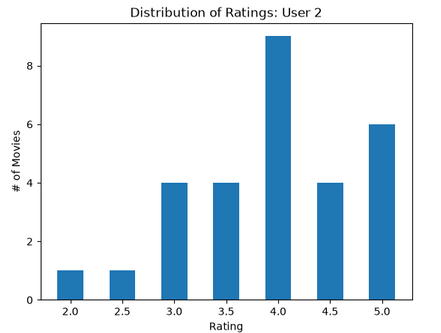

User 2's Top 6 Movies were:
- Step Brothers
- Inside Job
- Warrior
- Wolf of Wall Street, The
- Mad Max: Fury Road
- The Jinx: The Life and Deaths of Robert Durst

This is a mix of comedy, drama, action, and documentary genres.

**Collaborative Filtering**
Collaborative Filters were created using Pearson's Correlation, Euclidean Distance, and Cosine Distance methods. Interestingly, the top 4 similar users found using the Euclidean and Cosine methods were the same, but distinct from Pearson's method listing. These users were then fed into the MovieRecommender function to recommend highly rated movies from these users that were not rated by User 2. User 366 from the Pearson Method and User 461 from the Euclidean/Cosine Methods were selected. As a note, User 461 was 2nd on the list of distance from User 2 in the Euclidean/Cosine Methods; however, User 442 who was the first choice only recommended movies rated at 2.5/5 or lower. As such, there were no recommendations of 'good' movies from User 442.

**'Surprise' Filtering**
With little modification to the Week 6 FTE, I followed the coding and process of apply the Scikit-Surprise recommender to this dataset for User 2. It produced a selection of movies and the projected rating for each of them, which were unique from the recommendations of User 366 and User 461.

**Evaluation**
To evaluate which method to rely on, I compared the genre distribution of the top 10 recommended movies from User 366, 461, and the Surprise recommender to User 2's genre distribution.
| Genre | User 2 | User 366 | User 461 | Surprise |
| --- | --- | --- | --- | --- |
|'Adventure'| --- | 2.63% | 1.72% | 2.38% |
|'Mystery'| --- | 2.63% | 1.72% | 2.38% |
|'Musical'| --- | 2.63% | 1.72% | 2.38% |
|'Crime'| 1.85% | 2.63% | 1.72% | 2.38% |
|'Thriller'| 3.7% | 2.63% | 3.45% | 2.38% |
|'Western'| 3.7% | 2.63% | 3.45% | 2.38% |
|'Film-Noir'| 3.7% | 2.63% | 3.45% | 2.38% |
|'Drama'| 5.56% | 2.63% | 5.17% | 4.76% |
|'Action'| 7.41% | 5.26% | 6.9% | 4.76% |
|'Romance'| 7.41% | 5.26% | 6.9% | 7.14% |
|'Horror'| 7.41% | 5.26% | 6.9% | 7.14% |
|'IMAX'| 7.41%, | 5.26% | 6.9% | 7.14% |
|'Animation'| 7.41% | 7.89% | 6.9% | 7.14% |
|'War'| 7.41% | 7.89% | 6.9% | 7.14% |
|'Documentary'| 7.41% | 7.89% | 6.9% | 7.14% |
|'(no genres listed)'| 7.41% | 7.89% | 6.9% | 7.14% |
|'Children'| 7.41% | 7.89% | 6.9% | 7.14% |
|'Fantasy'| 7.41% | 7.89% | 6.9% | 7.14% |
|'Sci-Fi'| 7.41% | 7.89% | 8.62% | 7.14% |

Each method presented a similar pattern of genre distribution; however, User 366 seems to most closely match User 2 for the genre's most often rated by User 2. If I had to pick one, I would lean towards User 366's recommendations; however, a composite might be more fruitful and potentially yield more useful information to narrow down User 2's preferences.

Movie Recommendations for User 2 using the Pearson's Correlation Method (User 366):
|movie ID| movie title|user366 rating|global rating (relative)|
| --- | --- | --- | --- |
|1089|[Reservoir Dogs]|	5.0 | 550.5 |
|2959|[Fight Club]| 4.5 | 931.5|
|4993|[Lord of the Rings: The Fellowship of the Ring...| 4.5 | 813.0 |
|7153|[Lord of the Rings: The Return of the King, The]|	4.5 | 762.0 |
|8368|[Harry Potter and the Prisoner of Azkaban]| 4.5 |	364.0 |
